# Explore ingestion and alpha factors

Scratch notebook for pulling data through `src/data/ingest.py` and trying out the factor functions in `src/data/features.py` interactively. Nothing in here is part of the pipeline itself — it's just a place to poke at the functions and sanity-check the numbers.

Kernel: select **portfolio-constructor** (the project's `.venv`).

In [51]:
%load_ext autoreload
%autoreload 2
# Without this, editing a function in src/ won't take effect in this
# notebook until the kernel is restarted — Python caches modules on import
# and doesn't re-read them from disk on its own. autoreload watches for
# changes and reloads automatically before each cell runs.

import sys
from pathlib import Path

# Notebooks run with the notebook's own directory as the working directory,
# so the project root (parent of notebooks/) needs to be on sys.path for
# `from src import ...` imports to resolve.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data import ingest, features

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Pull data (cached after the first run)

In [39]:
tickers = config.TICKER_UNIVERSE + [config.BENCHMARK_TICKER]

prices_long = ingest.load_or_fetch_prices(tickers, config.DATA_START_DATE, config.DATA_END_DATE)
dividends = ingest.load_or_fetch_dividends(config.TICKER_UNIVERSE, config.DATA_START_DATE, config.DATA_END_DATE)

prices = ingest.to_wide_adj_close(prices_long)

print("prices_long:", prices_long.shape)
print("dividends:", dividends.shape)
print("prices (wide):", prices.shape)
prices.tail()

prices_long: (116240, 8)
dividends: (1614, 3)
prices (wide): (2906, 40)


ticker,AAPL,ABBV,AMZN,BA,BAC,CAT,COP,CSCO,CVX,DUK,...,SO,SPY,T,TSLA,UNH,UNP,VZ,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2026-07-20,326.589996,253.380005,249.990005,209.479996,60.419998,864.299988,115.680000,110.699997,189.710007,125.849998,...,94.459999,742.090027,21.950001,369.570007,421.549988,296.250000,43.500000,86.330002,112.199997,148.360001
2026-07-21,327.739990,256.100006,247.550003,204.800003,61.220001,889.969971,117.500000,112.180000,191.070007,125.910004,...,93.849998,748.280029,22.260000,378.929993,436.350006,293.130005,43.779999,87.739998,110.389999,151.710007
2026-07-22,325.890015,253.300003,244.850006,208.649994,61.619999,889.309998,118.790001,112.209999,192.979996,127.949997,...,95.800003,747.409973,23.040001,374.010010,431.309998,292.559998,44.290001,86.419998,109.330002,154.449997
2026-07-23,321.660004,256.920013,233.660004,209.229996,61.279999,894.539978,120.199997,112.760002,194.419998,129.259995,...,96.599998,738.179993,22.959999,319.690002,423.559998,304.329987,43.820000,86.190002,108.400002,156.889999
2026-07-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


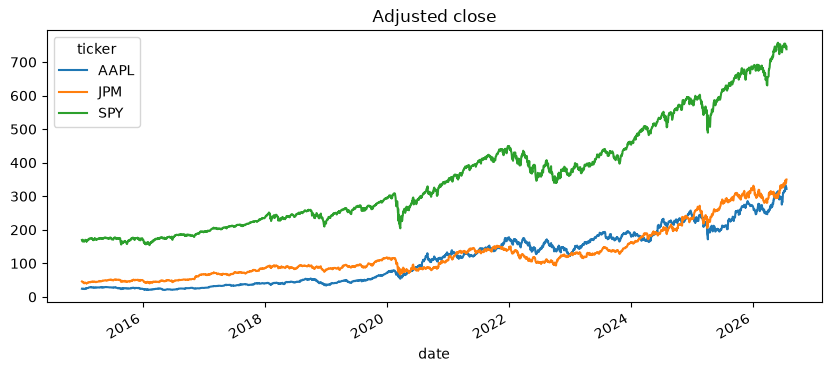

In [40]:
# Quick visual sanity check: do these look like real adjusted-close price series?
prices[["AAPL", "JPM", config.BENCHMARK_TICKER]].plot(figsize=(10, 4), title="Adjusted close")
plt.show()

## 2. Try the factor functions as of a given date

Each factor only uses price/dividend history strictly before `as_of_date` — change the date below and rerun to see the rankings shift.

In [41]:
as_of_date = pd.Timestamp("2026-07-18")

momentum = features.compute_momentum(prices, as_of_date)
low_volatility = features.compute_low_volatility(prices, as_of_date)
dividend_yield = features.compute_dividend_yield(dividends, prices, as_of_date)

factor_table = pd.DataFrame(
    {"momentum": momentum, "low_volatility": low_volatility, "dividend_yield": dividend_yield}
).drop(index=config.BENCHMARK_TICKER, errors="ignore")

factor_table.sort_values("momentum", ascending=False)

,momentum,low_volatility,dividend_yield
ticker,,,
INTC,4.800433,0.048828,0.000000
CAT,1.408666,0.024038,0.006874
GOOGL,0.994380,0.019270,0.002451
CSCO,0.786341,0.020597,0.014829
GS,0.579412,0.019327,0.015959
MRK,0.471697,0.017687,0.026353
UNH,0.456566,0.024946,0.021005
JNJ,0.430034,0.011351,0.020708
AAPL,0.416764,0.015423,0.003146


In [42]:
print("Top 5 momentum:")
print(factor_table["momentum"].sort_values(ascending=False).head())

print("\nTop 5 lowest volatility:")
print(factor_table["low_volatility"].sort_values().head())

print("\nTop 5 dividend yield:")
print(factor_table["dividend_yield"].sort_values(ascending=False).head())

Top 5 momentum:
ticker
INTC     4.800433
CAT      1.408666
GOOGL    0.994380
CSCO     0.786341
GS       0.579412
Name: momentum, dtype: float64

Top 5 lowest volatility:
ticker
DUK    0.009859
SO     0.010624
KO     0.011341
JNJ    0.011351
MCD    0.011377
Name: low_volatility, dtype: float64

Top 5 dividend yield:
ticker
PFE    0.069864
VZ     0.064143
T      0.050986
PEP    0.041927
CVX    0.037251
Name: dividend_yield, dtype: float64


## 3. Rank stocks and optimise a portfolio

Combine the three factors into one score, take the top `TOP_N_HOLDINGS`, then find mean-variance weights (Ledoit-Wolf shrinkage, max Sharpe) using the trailing `TRAIN_WINDOW_YEARS` of price history before `as_of_date` — the same window the real walk-forward backtest will use at each rebalance.

In [43]:
from src.models import ranker
from src.portfolio import optimise

# Use factor_table, not the raw momentum/low_volatility/dividend_yield series
# directly — factor_table already excludes the SPY benchmark column, and SPY
# must never be a candidate holding for the strategy itself.
scores = ranker.score_stocks(
    factor_table["momentum"], factor_table["low_volatility"], factor_table["dividend_yield"]
)
top_holdings = ranker.select_top_n(scores, n=config.TOP_N_HOLDINGS)

print(f"Top {config.TOP_N_HOLDINGS} holdings as of {as_of_date.date()}:")
print(list(top_holdings))

Top 15 holdings as of 2026-07-18:
['PFE', 'VZ', 'T', 'DUK', 'PEP', 'CVX', 'SO', 'JNJ', 'KO', 'MCD', 'PG', 'XOM', 'NEE', 'MRK', 'INTC']


In [44]:
window_start = as_of_date - pd.DateOffset(years=config.TRAIN_WINDOW_YEARS)
training_prices = prices.loc[
    (prices.index >= window_start) & (prices.index < as_of_date), list(top_holdings)
]
print("training window:", training_prices.index.min().date(), "to", training_prices.index.max().date())

weights = optimise.max_sharpe_weights(training_prices)
weights_series = pd.Series(weights).sort_values(ascending=False)
weights_series[weights_series > 0]

training window: 2023-07-18 to 2026-07-17


T       0.15000
DUK     0.15000
JNJ     0.15000
KO      0.15000
XOM     0.15000
INTC    0.10856
SO      0.07960
VZ      0.06184
dtype: float64

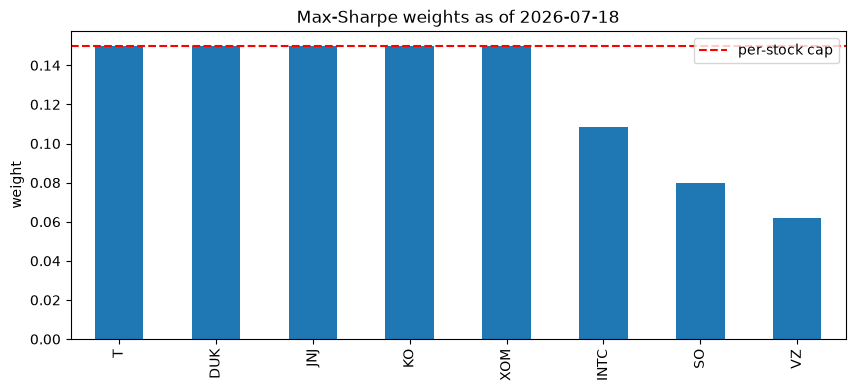

In [45]:
nonzero_weights = weights_series[weights_series > 0]
nonzero_weights.plot(
    kind="bar", figsize=(10, 4), title=f"Max-Sharpe weights as of {as_of_date.date()}"
)
plt.axhline(config.MAX_WEIGHT_PER_STOCK, color="red", linestyle="--", label="per-stock cap")
plt.legend()
plt.ylabel("weight")
plt.show()

## 4. Risk metrics

Turn the optimised weights into an actual daily return series, then run every metric in `src/risk/metrics.py` on it and compare against SPY.

Note: this holds the weights **statically over the whole available history** — it's a quick way to see the numbers, not the real walk-forward backtest (that rebalances monthly on a rolling training window, which is the next module to build).

In [46]:
from src.risk import metrics

held_tickers = list(nonzero_weights.index)
weights_vector = nonzero_weights / nonzero_weights.sum()  # renormalise away any rounding

held_prices = prices[held_tickers].dropna()
portfolio_returns = held_prices.pct_change().dropna().dot(weights_vector)
spy_returns = prices[config.BENCHMARK_TICKER].pct_change().dropna()

print("portfolio daily returns:", portfolio_returns.shape)
portfolio_returns.tail()

portfolio daily returns: (2904,)


date
2026-07-17   -0.008331
2026-07-20    0.002995
2026-07-21    0.015650
2026-07-22    0.013282
2026-07-23    0.001121
dtype: float64

In [47]:
aligned_spy_returns = spy_returns.loc[portfolio_returns.index]

comparison = pd.DataFrame(
    {"strategy": metrics.compute_all(portfolio_returns), "SPY": metrics.compute_all(aligned_spy_returns)}
)
comparison

,strategy,SPY
sharpe_ratio,0.622347,0.699046
sortino_ratio,0.803799,0.857827
max_drawdown,-0.333441,-0.337173
historical_var_95,-0.013750,-0.016585
monte_carlo_var_95,-0.015955,-0.018014
expected_shortfall_95,-0.022054,-0.026758
var_breaches_95,146.000000,146.000000
historical_var_99,-0.024574,-0.031624
monte_carlo_var_99,-0.022817,-0.025781
expected_shortfall_99,-0.040235,-0.045817


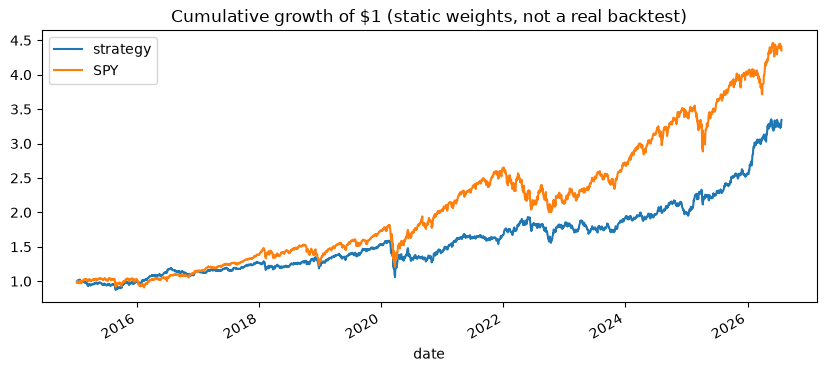

In [48]:
cumulative_growth = pd.DataFrame(
    {"strategy": (1 + portfolio_returns).cumprod(), "SPY": (1 + aligned_spy_returns).cumprod()}
)
cumulative_growth.plot(figsize=(10, 4), title="Cumulative growth of $1 (static weights, not a real backtest)")
plt.show()

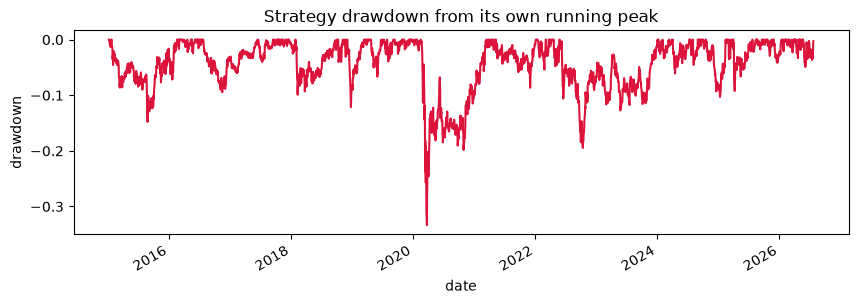

max drawdown: -0.33344073977502453


In [49]:
# Visualise max_drawdown: how far below its own running peak the strategy ever fell.
running_peak = cumulative_growth["strategy"].cummax()
drawdown = (cumulative_growth["strategy"] - running_peak) / running_peak

drawdown.plot(figsize=(10, 3), title="Strategy drawdown from its own running peak", color="crimson")
plt.ylabel("drawdown")
plt.show()

print("max drawdown:", drawdown.min())

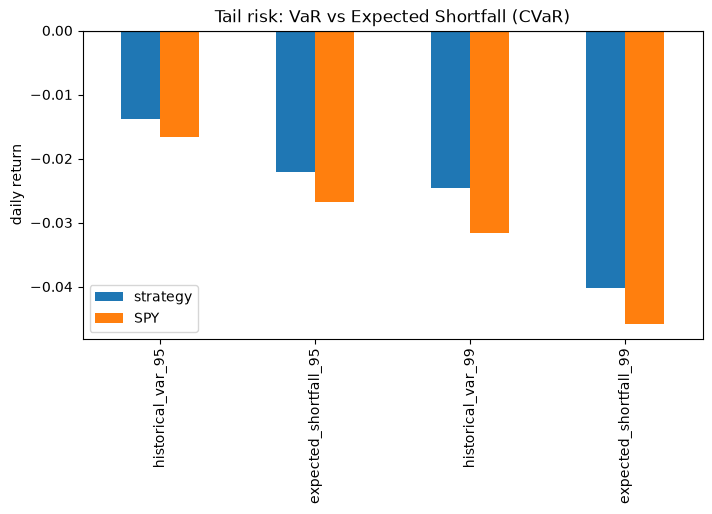

In [50]:
tail_risk_rows = [
    "historical_var_95",
    "expected_shortfall_95",
    "historical_var_99",
    "expected_shortfall_99",
]
comparison.loc[tail_risk_rows].plot(
    kind="bar", figsize=(8, 4), title="Tail risk: VaR vs Expected Shortfall (CVaR)"
)
plt.ylabel("daily return")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

## 5. The real walk-forward backtest

This is the actual thing, chaining everything above together: at every month-end from `BACKTEST_START_DATE` to `BACKTEST_END_DATE`, rank + optimise on the trailing `TRAIN_WINDOW_YEARS` window (never the future, never full history), hold until the next rebalance, and compare against equal-weight and SPY buy-and-hold — all reported gross and net of the `TRANSACTION_COST_BPS` cost.

Takes a few seconds to run (~90 monthly rebalances, each running the full rank → optimise pipeline).

In [38]:
from src.portfolio import backtest

daily_returns, rebalance_log = backtest.run_backtest(prices, dividends)

print("daily_returns:", daily_returns.shape)
print("rebalance_log:", rebalance_log.shape, "rebalances")
daily_returns.tail()

daily_returns: (1863, 6)
rebalance_log: (90, 4) rebalances


,strategy_gross,strategy_net,equal_weight_gross,equal_weight_net,sp500_gross,sp500_net
date,,,,,,
2026-06-24,-0.004704,-0.004704,-0.001640,-0.001640,-0.000464,-0.000464
2026-06-25,0.005330,0.005330,-0.000732,-0.000732,0.001446,0.001446
2026-06-26,0.015624,0.015624,0.004180,0.004180,-0.007231,-0.007231
2026-06-29,-0.011196,-0.011196,0.002169,0.002169,0.016475,0.016475
2026-06-30,0.000000,-0.000226,0.000000,-0.000091,0.007787,0.007787


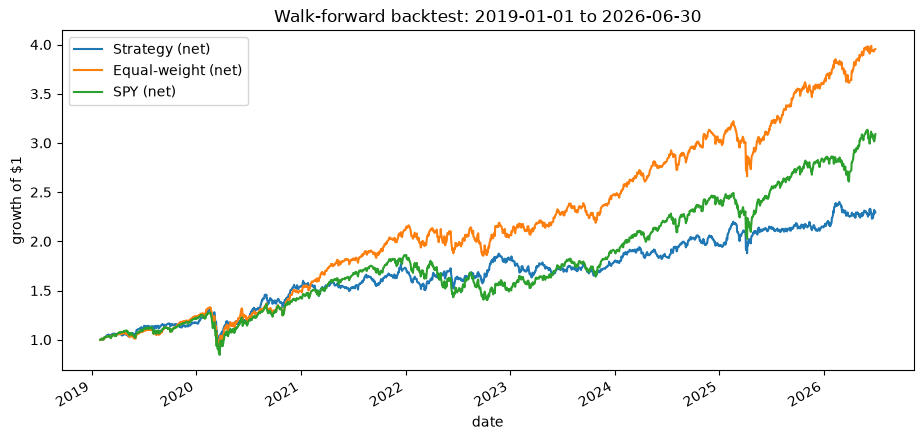

In [39]:
cumulative = (1 + daily_returns[["strategy_net", "equal_weight_net", "sp500_net"]]).cumprod()
cumulative.columns = ["Strategy (net)", "Equal-weight (net)", "SPY (net)"]

cumulative.plot(
    figsize=(11, 5),
    title=f"Walk-forward backtest: {config.BACKTEST_START_DATE} to {config.BACKTEST_END_DATE}",
)
plt.ylabel("growth of $1")
plt.show()

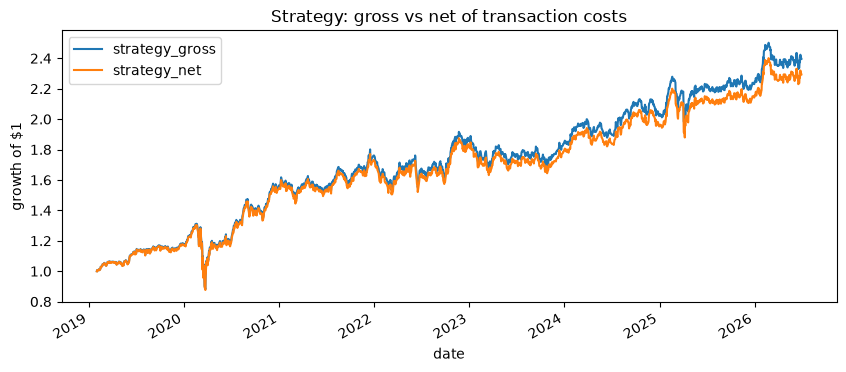

total transaction cost paid (sum of per-rebalance cost): 0.043818856095920844
final gross - final net: 0.10275593420685603


In [40]:
# How much do transaction costs actually cost the strategy over the whole backtest?
gross_vs_net = (1 + daily_returns[["strategy_gross", "strategy_net"]]).cumprod()
gross_vs_net.plot(figsize=(10, 4), title="Strategy: gross vs net of transaction costs")
plt.ylabel("growth of $1")
plt.show()

print("total transaction cost paid (sum of per-rebalance cost):", rebalance_log["cost"].sum())
print("final gross - final net:", gross_vs_net.iloc[-1, 0] - gross_vs_net.iloc[-1, 1])

In [41]:
backtest_comparison = pd.DataFrame(
    {
        "strategy": metrics.compute_all(daily_returns["strategy_net"]),
        "equal_weight": metrics.compute_all(daily_returns["equal_weight_net"]),
        "SPY": metrics.compute_all(daily_returns["sp500_net"]),
    }
)
backtest_comparison

,strategy,equal_weight,SPY
sharpe_ratio,0.611852,1.016483,0.778942
sortino_ratio,0.753571,1.192044,0.953946
max_drawdown,-0.327758,-0.341291,-0.337173
historical_var_95,-0.013737,-0.014781,-0.017436
monte_carlo_var_95,-0.018090,-0.018095,-0.019845
expected_shortfall_95,-0.024476,-0.026607,-0.029236
var_breaches_95,94.000000,94.000000,94.000000
historical_var_99,-0.026300,-0.030315,-0.033974
monte_carlo_var_99,-0.025863,-0.025993,-0.028425
expected_shortfall_99,-0.048954,-0.051017,-0.051986


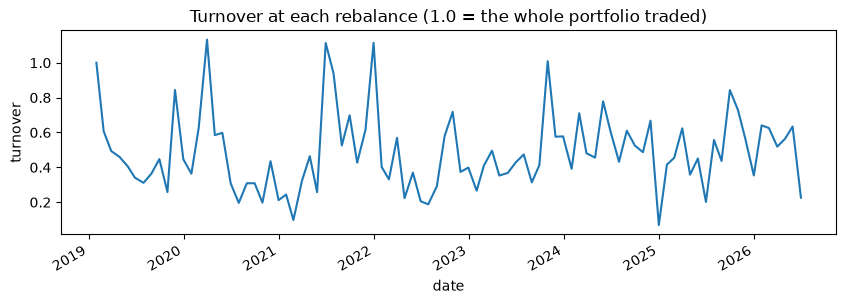

date
2019-01-31    [T, DUK, MRK, PFE, VZ, SO, NEE, KO, PG, PEP, M...
2022-10-31    [VZ, T, ABBV, SO, IBM, XOM, DUK, CVX, JNJ, KO,...
2026-06-30    [PFE, VZ, CVX, T, DUK, PEP, SO, JNJ, XOM, KO, ...
Name: selected_tickers, dtype: object

In [42]:
rebalance_log["turnover"].plot(
    figsize=(10, 3), title="Turnover at each rebalance (1.0 = the whole portfolio traded)"
)
plt.ylabel("turnover")
plt.show()

# How the actual holdings evolved — pick a few rebalance dates to eyeball.
rebalance_log["selected_tickers"].iloc[[0, len(rebalance_log) // 2, -1]]

### Holdings and weights over time

`rebalance_log["weights"]` holds a `{ticker: weight}` dict for every rebalance date. Reshaping that into a wide date × ticker table and plotting it as a heatmap (ticker on the y-axis, date on the x-axis, color = weight) shows how the portfolio's composition evolved — with 36 distinct tickers appearing at some point, a heatmap reads far more clearly than trying to tell that many colors apart in a stacked chart.

In [43]:
holdings_over_time = pd.DataFrame(list(rebalance_log["weights"]), index=rebalance_log.index).fillna(0.0)

# Order columns by total weight held over the whole backtest, so the most
# persistent holdings group together in the chart instead of appearing in
# whatever order dict keys happened to come out in.
holdings_over_time = holdings_over_time[holdings_over_time.sum().sort_values(ascending=False).index]

print(f"{(holdings_over_time > 0).any().sum()} distinct tickers held at some point")
holdings_over_time.tail()

36 distinct tickers held at some point


,SO,ABBV,MRK,PG,MCD,PEP,WMT,KO,IBM,JNJ,...,AAPL,ORCL,HON,GOOGL,WFC,UNH,UNP,NVDA,BAC,META
date,,,,,,,,,,,,,,,,,,,,,
2026-02-27,0.15000,0.0,0.00000,0.0,0.0,0.0,0.0,0.15000,0.0,0.15,...,0.0,0.0,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-31,0.09687,0.0,0.00000,0.0,0.0,0.0,0.0,0.08028,0.0,0.15,...,0.0,0.0,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.0
2026-04-30,0.04591,0.0,0.00000,0.0,0.0,0.0,0.0,0.15000,0.0,0.15,...,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0
2026-05-29,0.08966,0.0,0.00000,0.0,0.0,0.0,0.0,0.15000,0.0,0.15,...,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0
2026-06-30,0.15000,0.0,0.02911,0.0,0.0,0.0,0.0,0.15000,0.0,0.15,...,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0


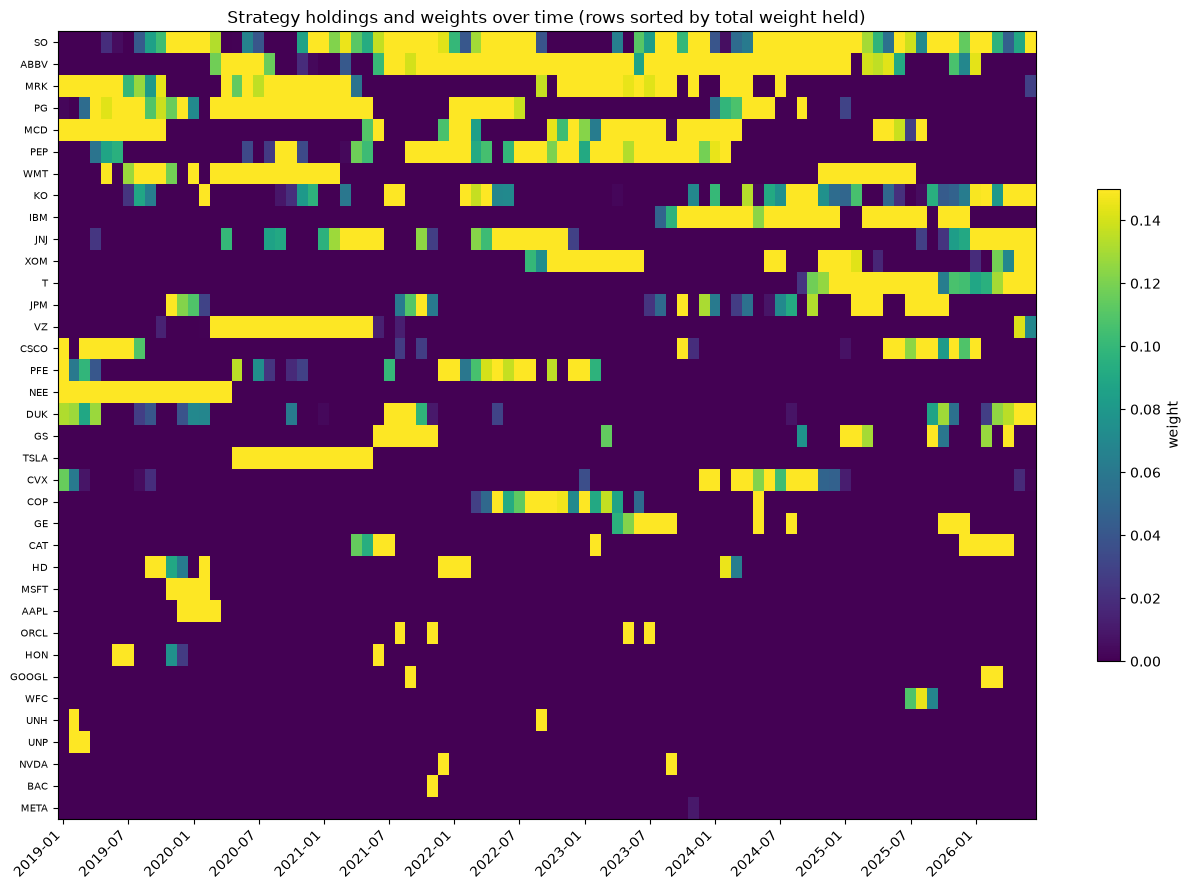

In [46]:
heatmap_data = holdings_over_time.T  # tickers as rows, dates as columns

fig, ax = plt.subplots(figsize=(13, 9))
image = ax.imshow(heatmap_data.values, aspect="auto", cmap="viridis", vmin=0)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=7)

# Showing every one of ~90 rebalance dates would be unreadable — space them out.
tick_step = max(1, len(heatmap_data.columns) // 15)
tick_positions = list(range(0, len(heatmap_data.columns), tick_step))
ax.set_xticks(tick_positions)
ax.set_xticklabels(
    [heatmap_data.columns[i].strftime("%Y-%m") for i in tick_positions], rotation=45, ha="right"
)

ax.set_title("Strategy holdings and weights over time (rows sorted by total weight held)")
fig.colorbar(image, ax=ax, label="weight", shrink=0.6)
plt.tight_layout()
plt.show()

In [47]:
# Same information as a table, for exact numbers rather than reading them off the chart.
# Only columns held at some point in the last 6 rebalances, blanks instead of 0.000 for readability.
recent = holdings_over_time.tail(6)
recent = recent.loc[:, (recent > 0).any()]
recent.round(3).replace(0, "")

,SO,ABBV,MRK,KO,JNJ,XOM,T,VZ,CSCO,DUK,GS,CVX,CAT,GOOGL
date,,,,,,,,,,,,,,
2026-01-30,0.150,0.144,,0.148,0.15,0.019,0.089,,0.15,,,,0.15,
2026-02-27,0.150,,,0.150,0.15,,0.096,,,0.028,0.127,,0.15,0.15
2026-03-31,0.097,,,0.080,0.15,0.118,0.130,,,0.125,,,0.15,0.15
2026-04-30,0.046,,,0.150,0.15,0.07,0.150,,,0.134,0.15,,0.15,
2026-05-29,0.090,,,0.150,0.15,0.15,0.150,0.142,,0.15,,0.018,,
2026-06-30,0.150,,0.029,0.150,0.15,0.15,0.150,0.069,,0.15,,0.002,,


## 6. Momentum-only variant: does it capture the mega-cap winners?

The strategy above avoids NVDA/META/TSLA/AMZN/GOOGL almost entirely — the low-volatility and dividend-yield legs of the composite score structurally penalise high-volatility, low/no-dividend growth names, even in months when their momentum is strong.

`ranker.score_by_momentum_only` drops those two legs and ranks purely on momentum, the classic academic momentum factor (Jegadeesh & Titman, 1993). Same walk-forward mechanics, same optimiser, same cost model — just a different ranking rule, swapped in via `run_backtest`'s `score_fn` parameter.

In [48]:
momentum_returns, momentum_log = backtest.run_backtest(prices, dividends, score_fn=ranker.score_by_momentum_only)

print("Holdings at the most recent rebalance:")
print("  composite (current strategy):", rebalance_log["selected_tickers"].iloc[-1])
print("  momentum-only:               ", momentum_log["selected_tickers"].iloc[-1])

Holdings at the most recent rebalance:
  composite (current strategy): ['PFE', 'VZ', 'CVX', 'T', 'DUK', 'PEP', 'SO', 'JNJ', 'XOM', 'KO', 'MCD', 'NEE', 'PG', 'MRK', 'COP']
  momentum-only:                ['INTC', 'CAT', 'GOOGL', 'CSCO', 'MRK', 'AAPL', 'JNJ', 'GS', 'XOM', 'TSLA', 'NVDA', 'CVX', 'COP', 'NEE', 'GE']


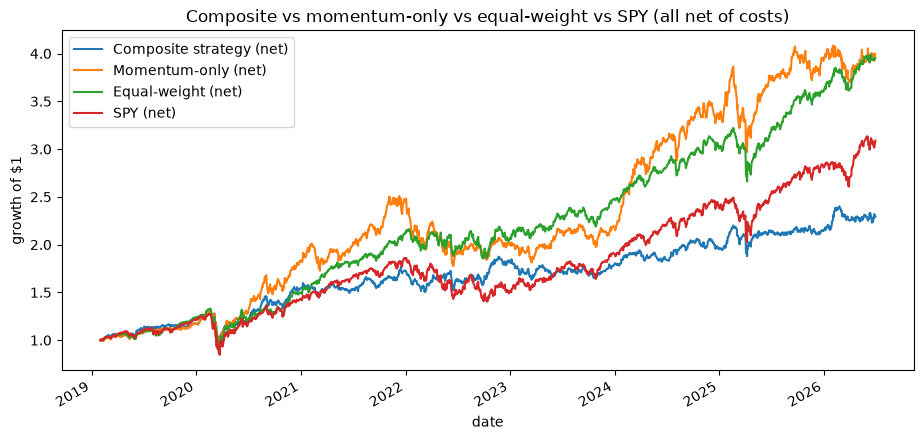

In [49]:
four_way = pd.DataFrame(
    {
        "Composite strategy (net)": daily_returns["strategy_net"],
        "Momentum-only (net)": momentum_returns["strategy_net"],
        "Equal-weight (net)": daily_returns["equal_weight_net"],
        "SPY (net)": daily_returns["sp500_net"],
    }
)
(1 + four_way).cumprod().plot(
    figsize=(11, 5), title="Composite vs momentum-only vs equal-weight vs SPY (all net of costs)"
)
plt.ylabel("growth of $1")
plt.show()

In [50]:
four_way_comparison = pd.DataFrame(
    {
        "composite": metrics.compute_all(daily_returns["strategy_net"]),
        "momentum_only": metrics.compute_all(momentum_returns["strategy_net"]),
        "equal_weight": metrics.compute_all(daily_returns["equal_weight_net"]),
        "SPY": metrics.compute_all(daily_returns["sp500_net"]),
    }
)
four_way_comparison

,composite,momentum_only,equal_weight,SPY
sharpe_ratio,0.611852,0.885559,1.016483,0.778942
sortino_ratio,0.753571,1.109423,1.192044,0.953946
max_drawdown,-0.327758,-0.327841,-0.341291,-0.337173
historical_var_95,-0.013737,-0.020228,-0.014781,-0.017436
monte_carlo_var_95,-0.018090,-0.021872,-0.018095,-0.019845
expected_shortfall_95,-0.024476,-0.031541,-0.026607,-0.029236
var_breaches_95,94.000000,94.000000,94.000000,94.000000
historical_var_99,-0.026300,-0.035117,-0.030315,-0.033974
monte_carlo_var_99,-0.025863,-0.031363,-0.025993,-0.028425
expected_shortfall_99,-0.048954,-0.055585,-0.051017,-0.051986


## 7. Run full pipeline

In [52]:
from src.data import pipeline

In [53]:
pipeline.run_pipeline()

{'prices': ticker            AAPL        ABBV        AMZN          BA        BAC  \
 date                                                                    
 2015-01-02   24.192610   41.119232   15.426000  113.657219  14.050797   
 2015-01-05   23.511065   40.345394   15.109500  112.870056  13.642616   
 2015-01-06   23.513277   40.145691   14.764500  111.540619  13.234433   
 2015-01-07   23.842983   41.768253   14.921000  113.272354  13.297232   
 2015-01-08   24.759077   42.205097   15.023000  115.275291  13.571971   
 ...                ...         ...         ...         ...        ...   
 2026-07-20  326.589996  253.380005  249.990005  209.479996  60.419998   
 2026-07-21  327.739990  256.100006  247.550003  204.800003  61.220001   
 2026-07-22  325.890015  253.300003  244.850006  208.649994  61.619999   
 2026-07-23  321.660004  256.920013  233.660004  209.229996  61.279999   
 2026-07-24         NaN         NaN         NaN         NaN        NaN   
 
 ticker             CAT   